In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet

from sklearn.ensemble import HistGradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [101]:
df = pd.read_csv("../data/processed/rideshare_feature_engineering.csv")

In [102]:
df.head()

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,log_distance,surge_intensity,price_per_mile,is_surge,source_avg_price,dest_avg_price,cab_type_enc,destination_enc,route_frequency,source_enc
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,0.364643,0.0,11.337868,0,13.578114,16.805238,1,7,8874,5
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,0.364643,0.0,24.943311,0,13.578114,16.805238,1,7,8874,5
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,0.364643,0.0,15.873016,0,13.578114,16.805238,1,7,8874,5
3,4,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,26.0,0.44,1.0,...,0.364643,0.0,58.956916,0,13.578114,16.805238,1,7,8874,5
4,3,29,11,Haymarket Square,North Station,Lyft,Lyft XL,9.0,0.44,1.0,...,0.364643,0.0,20.408163,0,13.578114,16.805238,1,7,8874,5


In [103]:
df.columns

Index(['hour', 'day', 'month', 'source', 'destination', 'cab_type', 'name',
       'price', 'distance', 'surge_multiplier', 'latitude', 'longitude',
       'temperature', 'apparentTemperature', 'short_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax', 'tier', 'route',
       'log_price', 'tier_enc', 'name_enc', 'surge_x_distance', 'log_distance',
       'surge_intensity', 'price_per_mile', 'is_surge', 'source_avg_price',
       'dest_avg_price', 'cab_type_enc', 'destination_enc', 'route_frequency',
       'source_enc'],
      dtype='str')

In [104]:
print(df.select_dtypes(include=['object']).columns)

Index(['source', 'destination', 'cab_type', 'name', 'short_summary', 'tier',
       'route'],
      dtype='str')


C:\Users\teera\AppData\Local\Temp\ipykernel_9456\845905018.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns)


In [105]:
weather = ['latitude', 'longitude',
       'temperature', 'apparentTemperature', 'short_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'visibility', 'temperatureHigh', 'temperatureLow',
       'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint',
       'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone',
       'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax',
       'apparentTemperatureMin', 'apparentTemperatureMax']

time = ['hour', 'day', 'month']

encoded = ['source', 'destination', 'cab_type', 'name', 'short_summary', 'tier', 'route','short_summary', 'distance']

data_leakage =  ['source_avg_price','dest_avg_price', 'log_price', 'price']

drop_columns = weather + time + encoded + data_leakage

df_final = df.drop(columns=drop_columns, errors='ignore')

X = df_final
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
df_final.columns

Index(['surge_multiplier', 'tier_enc', 'name_enc', 'surge_x_distance',
       'log_distance', 'surge_intensity', 'price_per_mile', 'is_surge',
       'cab_type_enc', 'destination_enc', 'route_frequency', 'source_enc'],
      dtype='str')

In [ ]:
# Baseline
# Linear Models แก้ Overfit ด้วย Regularization
# XGBoost
# HistGradientBoosting
# LightGBM

model_configs = [
    {
        'name': 'LinearReg',
        'model': LinearRegression(),
        'params': {}
    },
    {
        'name': 'Lasso',
        'model': Lasso(),
        'params': {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    },
    {
        'name': 'ElasticNet',
        'model': ElasticNet(),
        'params': {
            'alpha': [0.001, 0.01, 0.1, 1, 10],
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBRegressor(n_jobs=-1, random_state=42),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9]
        }
    },
    {
        'name': 'HistGBM',
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [1000, 2000, 5000],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 500],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'num_leaves': [7, 31, 127]
        }
    }
]

Model        | Best RMSE    | Best Params
LinearReg    | 4.9479       | N/A
Lasso        | 4.9479       | {'alpha': 0.001}
ElasticNet   | 4.9483       | {'l1_ratio': 0.2, 'alpha': 0.001}
XGBoost      | 0.3029       | {'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.01}
HistGBM      | 0.1896       | {'max_iter': 2000, 'max_depth': 6, 'learning_rate': 0.1}
LightGBM     | 0.8053       | {'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}


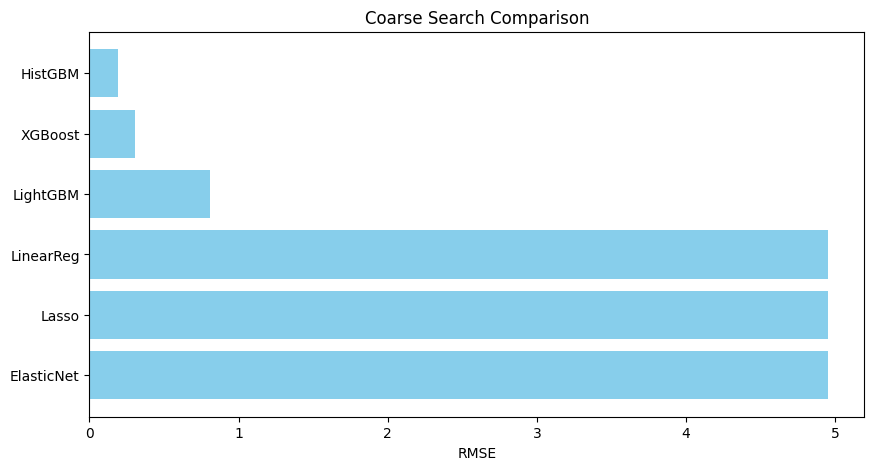

In [ ]:
# Coarse Search
summary_results = []

print(f"{'Model':<12} | {'Best RMSE':<12} | {'Best Params'}")

for config in model_configs:
    if config['name'] == 'LinearReg':
        scores = cross_val_score(config['model'], X_train, y_train, cv=3, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores.mean())
        best_params = "N/A"
    else:
        search = RandomizedSearchCV(
            config['model'], 
            config['params'], 
            n_iter=5, 
            cv=3, 
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            random_state=42
        )
        search.fit(X_train, y_train)
        rmse = np.sqrt(-search.best_score_)
        best_params = search.best_params_

    summary_results.append({'Model': config['name'], 'RMSE': rmse})
    print(f"{config['name']:<12} | {rmse:<12.4f} | {best_params}")


res_df = pd.DataFrame(summary_results).sort_values('RMSE')
plt.figure(figsize=(10, 5))
plt.barh(res_df['Model'], res_df['RMSE'], color='skyblue')
plt.xlabel('RMSE')
plt.title('Coarse Search Comparison')
plt.gca().invert_yaxis()
plt.show()

In [109]:
fine_configs = [
    {
        'name': 'XGBoost',
        'model': XGBRegressor(n_jobs=-1, random_state=42),
        'params': {
            'n_estimators': [500, 800, 1000],
            'learning_rate': [0.005, 0.01, 0.015],
            'max_depth': [8, 9, 10, 12]
        }
    },
    {
        'name': 'HistGBM',
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [2000, 2800, 3400],
            'learning_rate': [0.075, 0.1, 0.125],
            'max_depth': [5, 6, 7]
        }
    },
    {
        'name': 'LightGBM',
        'model': LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [150, 200, 250, 300],
            'learning_rate': [0.05, 0.075, 0.1, 0.125],
            'max_depth': [2, 3, 4, 5],
            'num_leaves': [3, 7, 15, 24]
        }
    },
]

Model        | Fine RMSE    | Best Params
XGBoost      | 0.1919       | {'learning_rate': 0.015, 'max_depth': 12, 'n_estimators': 1000}
HistGBM      | 0.1787       | {'learning_rate': 0.1, 'max_depth': 7, 'max_iter': 2800}
LightGBM     | 0.3586       | {'learning_rate': 0.125, 'max_depth': 5, 'n_estimators': 300, 'num_leaves': 24}


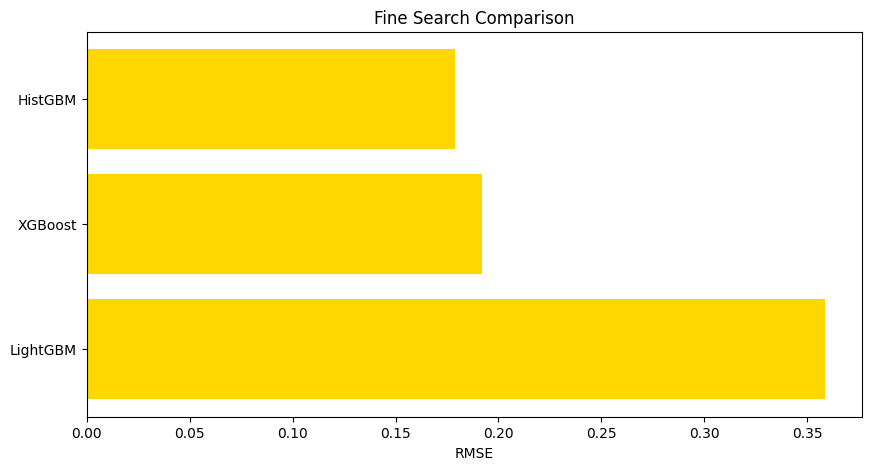

In [110]:
# Fine Search
fine_summary = []

print(f"{'Model':<12} | {'Fine RMSE':<12} | {'Best Params'}")

for config in fine_configs:
    grid = GridSearchCV(
        config['model'], 
        config['params'], 
        cv=6, 
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    
    rmse = np.sqrt(-grid.best_score_)
    fine_summary.append({
        'Model': config['name'], 
        'RMSE': rmse, 
        'BestModel': grid.best_estimator_
    })
    
    print(f"{config['name']:<12} | {rmse:<12.4f} | {grid.best_params_}")

fine_res_df = pd.DataFrame(fine_summary).sort_values('RMSE')
plt.figure(figsize=(10, 5))
plt.barh(fine_res_df['Model'], fine_res_df['RMSE'], color='gold')
plt.xlabel('RMSE')
plt.title('Fine Search Comparison')
plt.gca().invert_yaxis()
plt.show()

=== Final Evaluation on Test Set ===
Final RMSE: 0.1739
Final R2 Score: 0.9997


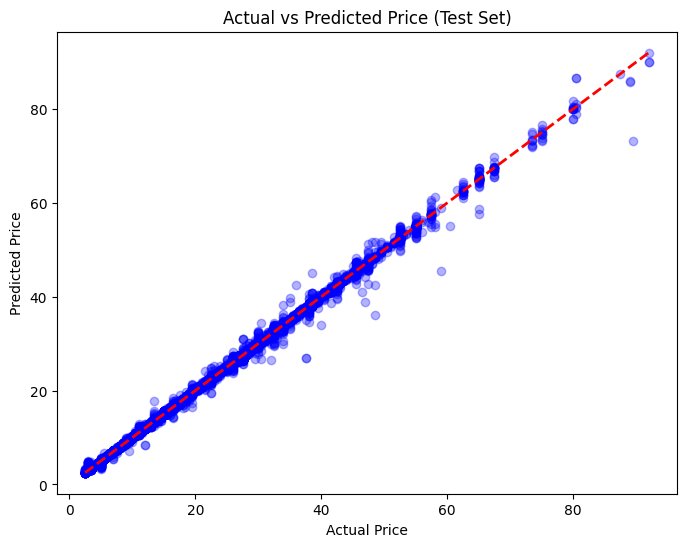

In [ ]:
best_model = fine_summary[0]['BestModel']

# Predict Test
y_pred = best_model.predict(X_test)

# คำนวณ Error
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f"Final Evaluation on Test Set")
print(f"Final RMSE: {final_rmse:.4f}")
print(f"Final R2 Score: {final_r2:.4f}")

# Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price (Test Set)')
plt.show()